#### inspecting the dataset (adjusted code from GNN exercise)

In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
import os
import awkward
from matplotlib import pyplot as plt
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
#from torch_geometric.data import Data, Batch

from helper import normalize_x, normalize_y, normalize_time, denormalize, collate_fn_transformer, normalize_data
DATA_PATH = "../B04/IceCube_2D_Dataset/"  # path to the data

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")


The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

#### normalize data

In [2]:
norm_train_data = normalize_data(train_dataset)
norm_val_data = normalize_data(val_dataset)
norm_test_data = normalize_data(test_dataset)

target_x_mean = awkward.mean(train_dataset["xpos"])
target_x_std = awkward.std(train_dataset["xpos"])

target_y_mean = awkward.mean(train_dataset["ypos"])
target_y_std = awkward.std(train_dataset["ypos"])

#### data loaders

In [3]:
batch_size = 32

train_loader = DataLoader(norm_train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(norm_val_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(norm_test_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)

#### transformer encoder

In [4]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim=3,#time, x, y
        hidden_dim=128,
        output_dim=2,#x, y
        nhead=4,          
        num_layers=3,    
        dim_feedforward=128,
    )-> None:
        super().__init__()

        # Hint: define the input embedding layer
        self.embedding = nn.Linear(input_dim, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, #.
            nhead=nhead,#.
            dim_feedforward=dim_feedforward,#.
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=0.02
        )

        # encoder layers
        self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
        # Hint: define the output projection layer
        self.output = nn.Linear(hidden_dim, output_dim)


    def forward(self, data):
        """
        Args:
            data: list of (src tensor, lengths) src: (total_hits, input_dim), lengths: # of hits per event
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
        src = self.embedding(src)
        # shape (B x N, F) -> (B x N, D)

        # 2) split the data into a list of tensors, one for each event
        parts = src.split(lengths, dim=0) # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
        # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event

        # 3) pad inputs with zeros so that all batch items have same length
        
        padded = pad_sequence(parts, batch_first=True) # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length

        batch_size, max_len, _ = padded.shape

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)

        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded,src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask

        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)

        pooled = summed / torch.LongTensor(lengths)[:, None].to(enc_out)

        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        out = self.output(pooled)
        return out


#### set network parameters

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerEncoder(
        input_dim=3,#time, x, y
        hidden_dim=128,
        output_dim=2,#x, y
        nhead=4,          
        num_layers=3,    
        dim_feedforward=128,
        ).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)


/tmp/ipykernel_98565/3218291121.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html


#### training and validation

In [6]:
num_epochs = 30

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for data, target in train_loader:

        src, lengths = data
        src = src.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model((src, lengths))

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for data, target in test_loader:
            src, lengths = data
            src = src.to(device)
            target = target.to(device)

            output = model((src, lengths))
            loss = criterion(output, target)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch  1/30 | Train Loss: 0.2864 | Validation Loss: 0.1668
Epoch  2/30 | Train Loss: 0.1717 | Validation Loss: 0.1613
Epoch  3/30 | Train Loss: 0.1639 | Validation Loss: 0.1679
Epoch  4/30 | Train Loss: 0.1594 | Validation Loss: 0.2031
Epoch  5/30 | Train Loss: 0.1586 | Validation Loss: 0.1603
Epoch  6/30 | Train Loss: 0.1547 | Validation Loss: 0.1571
Epoch  7/30 | Train Loss: 0.1525 | Validation Loss: 0.1754
Epoch  8/30 | Train Loss: 0.1529 | Validation Loss: 0.1576
Epoch  9/30 | Train Loss: 0.1585 | Validation Loss: 0.1501
Epoch 10/30 | Train Loss: 0.1509 | Validation Loss: 0.1609
Epoch 11/30 | Train Loss: 0.1474 | Validation Loss: 0.1395
Epoch 12/30 | Train Loss: 0.1440 | Validation Loss: 0.1536
Epoch 13/30 | Train Loss: 0.1393 | Validation Loss: 0.1496
Epoch 14/30 | Train Loss: 0.1430 | Validation Loss: 0.1464
Epoch 15/30 | Train Loss: 0.1340 | Validation Loss: 0.1518
Epoch 16/30 | Train Loss: 0.1310 | Validation Loss: 0.1462
Epoch 17/30 | Train Loss: 0.1310 | Validation Loss: 0.14

#### testing

In [7]:
model.eval()

predictions = []
targets = []

with torch.no_grad():
    for data, target in test_loader:
        src, lengths = data
        pred = model((src.to(device), lengths))

        predictions.append(pred.cpu())
        targets.append(target)

predictions = torch.cat(predictions).numpy()
targets = torch.cat(targets).numpy()

predictions = denormalize(predictions,target_x_mean,target_x_std,target_y_mean,target_y_std)
targets = denormalize(targets,target_x_mean,target_x_std,target_y_mean,target_y_std)

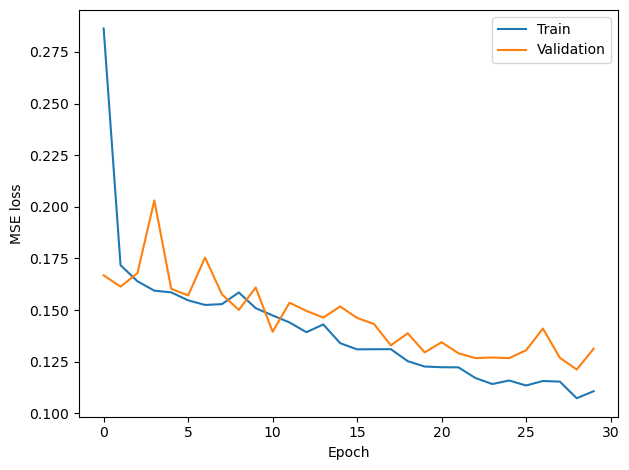

In [37]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
#plt.title("Loss curves")
plt.legend()
plt.tight_layout()
plt.savefig("images/loss.png")
plt.show()


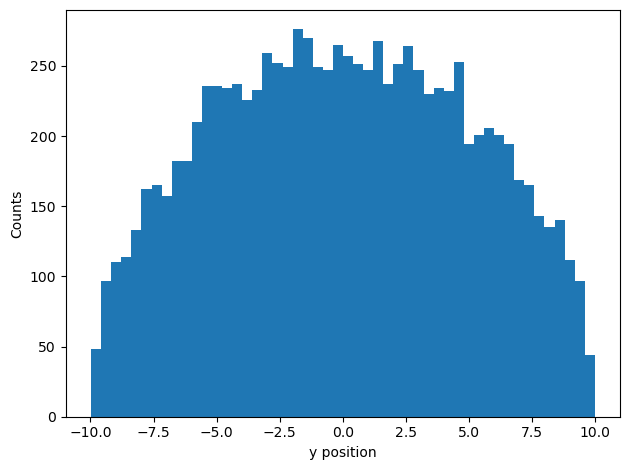

In [9]:
plt.hist(train_dataset["ypos"], bins=50)
plt.xlabel("y position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

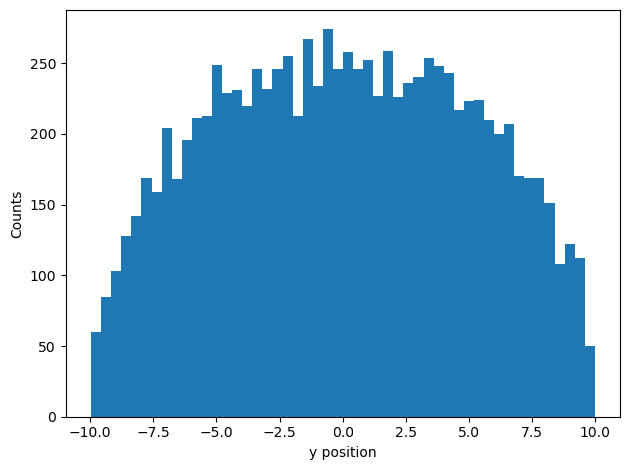

In [10]:
plt.hist(val_dataset["ypos"], bins=50)
plt.xlabel("y position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

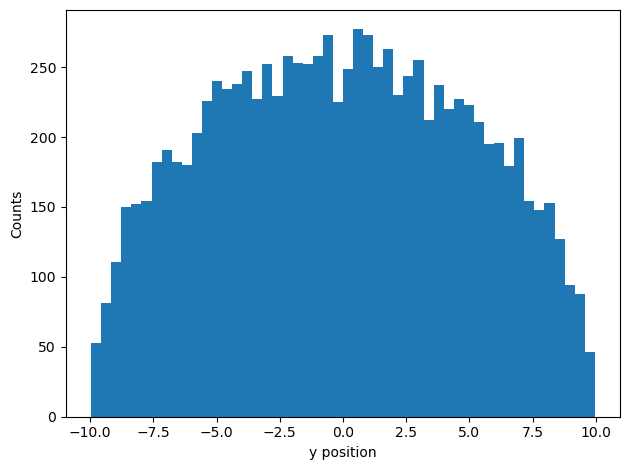

In [11]:
plt.hist(test_dataset["ypos"], bins=50)
plt.xlabel("y position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

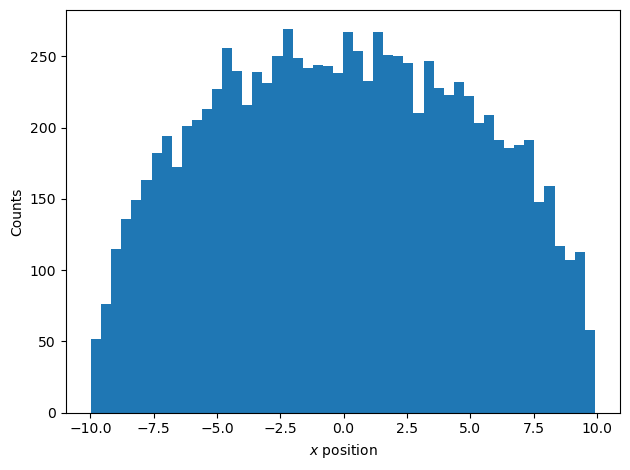

In [12]:
plt.hist(train_dataset["xpos"], bins=50)
plt.xlabel(r"$x$ position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

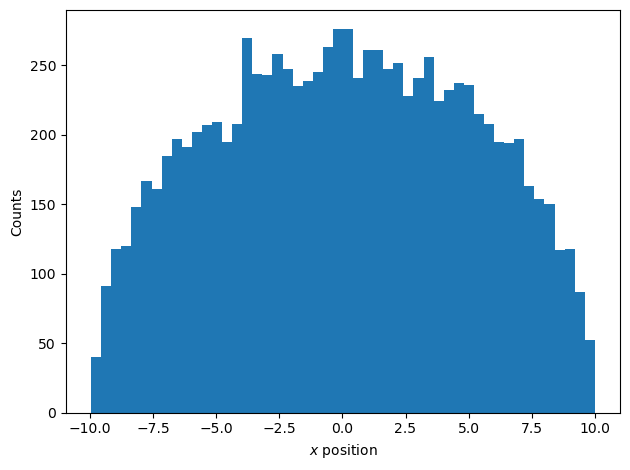

In [13]:
plt.hist(val_dataset["xpos"], bins=50)
plt.xlabel(r"$x$ position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

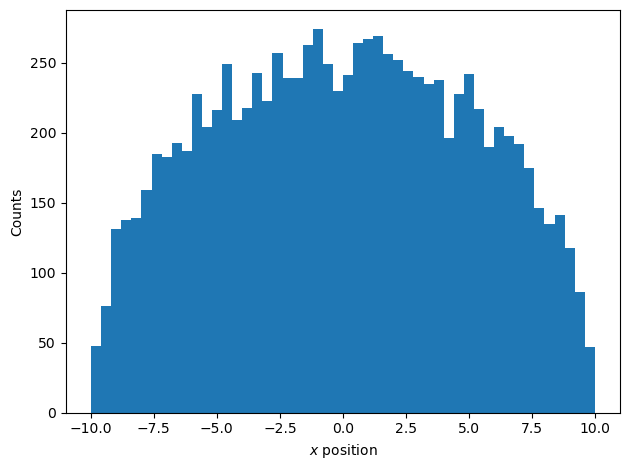

In [14]:
plt.hist(test_dataset["xpos"], bins=50)
plt.xlabel(r"$x$ position")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

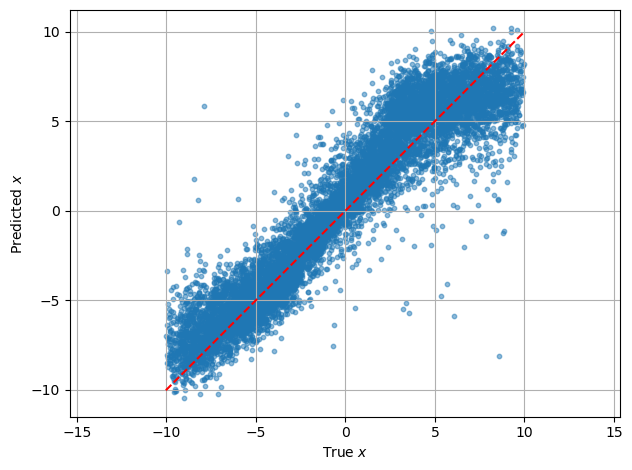

In [42]:
plt.scatter(targets[:,0], predictions[:,0], alpha=0.5, s=10, label="x")

plt.plot([targets[:,0].min(), targets[:,0].max()], [targets[:,0].min(), targets[:,0].max()], 'r--')

plt.xlabel(r"True $x$")
plt.ylabel(r"Predicted $x$")
#plt.title(r"Predicted vs true $x$-position")
plt.tight_layout()
plt.axis("equal")
plt.grid()
plt.savefig("images/true_vs_predicted_x.png")
plt.show()


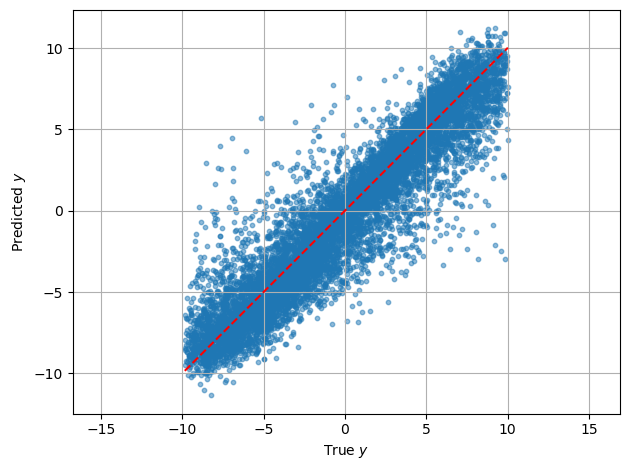

In [43]:
plt.scatter(targets[:,1], predictions[:,1], alpha=0.5, s=10, label="x")

plt.plot([targets[:,1].min(), targets[:,1].max()], [targets[:,1].min(), targets[:,1].max()], 'r--')

plt.xlabel(r"True $y$")
plt.ylabel(r"Predicted $y$")
#plt.title(r"Predicted vs true $y$-position")
plt.tight_layout()
plt.axis("equal")
plt.grid()
plt.savefig("images/true_vs_predicted_y.png")
plt.show()


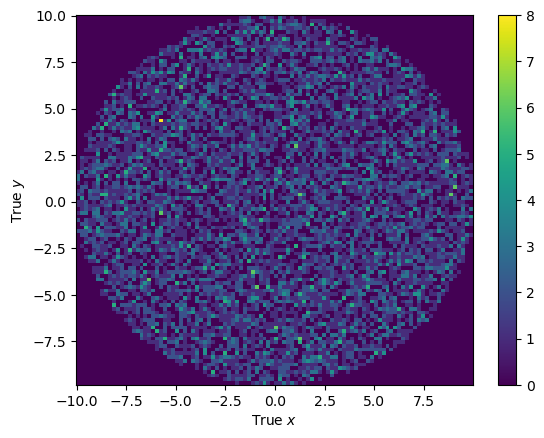

In [40]:
plt.hist2d(targets[:, 0],targets[:, 1],bins=100)

plt.xlabel(r"True $x$")
plt.ylabel(r"True $y$")

#plt.title("True interaction positions")

plt.colorbar()
plt.savefig("images/trueMap.png")
plt.show()


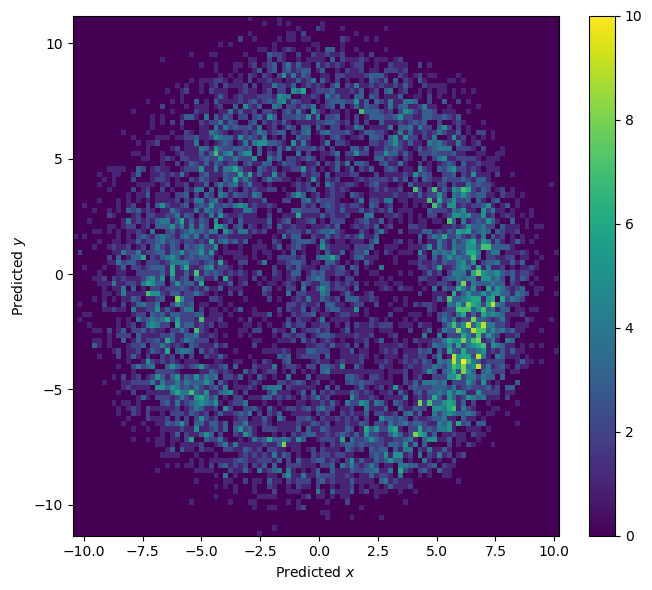

In [44]:
plt.figure(figsize=(7, 6))
plt.hist2d(predictions[:, 0],predictions[:, 1],bins=100)

plt.xlabel(r"Predicted $x$")
plt.ylabel(r"Predicted $y$")
#plt.title("Predicted interaction positions")

plt.colorbar()
plt.tight_layout()
plt.savefig("images/predictionMap.png")
plt.show()


In [19]:
dist_error = np.sqrt((predictions[:, 0] - targets[:, 0])**2+(predictions[:, 1] - targets[:, 1])**2)

print("Mean reconstruction error:",np.mean(dist_error))
print("Median reconstruction error:",np.median(dist_error))
print("Median reconstruction error for x:",np.median(targets[:,0]-predictions[:,0]))
print("Mean reconstruction error for x:",np.mean(targets[:,0]-predictions[:,0]))
print("Median reconstruction error for y:",np.median(targets[:,1]-predictions[:,1]))
print("Mean reconstruction error for y:",np.mean(targets[:,1]-predictions[:,1]))

Mean reconstruction error: 2.0663235
Median reconstruction error: 1.7184832
Median reconstruction error for x: -0.48412132
Mean reconstruction error for x: -0.4557624
Median reconstruction error for y: 0.19305801
Mean reconstruction error for y: 0.26403096


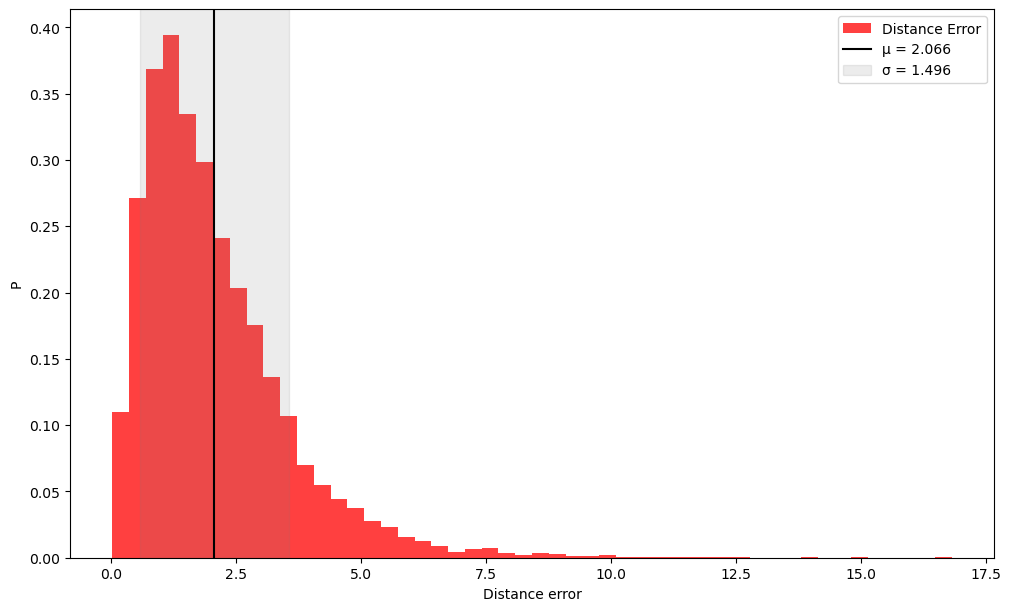

In [23]:
error = np.sqrt((predictions[:, 0] - targets[:, 0])**2 + (predictions[:, 1] - targets[:, 1])**2)
mean_error = error.mean()
std_error = error.std()

fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='constrained')

ax.hist(error, bins=50, density=True, color='red', alpha=0.75, label='Distance Error')
ax.axvline(x=mean_error, color='black', label=f'µ = {mean_error:.3f}')
ax.axvspan(xmin=mean_error-std_error, xmax=mean_error+std_error, color='gray', alpha=0.15, label=f'σ = {std_error:.3f}')
ax.set(
    xlabel=('Distance error'),
    ylabel=('P')
)
ax.legend()
plt.savefig("images/deviations.png")